**420-A58-SF - Algorithmes d'apprentissage non supervisé - Hiver 2026 - Spécialisation technique en Intelligence Artificielle**<br/>
MIT License - Copyright (c) 2026 Mikaël Swawola
<br/>
**Objectif:** cet atelier a pour objectif l'application de l'algorithme DBSCAN à la détection et localisation d'objets dans une image

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from skimage import data
from skimage.filters import threshold_otsu
from sklearn.cluster import DBSCAN

## 1 - Chargement et visualisation de l'image

Nous allons utiliser une image de pièces de monnaie (`coins`) provenant de la librairie scikit-image. Cette image est libre de droits et parfaitement adaptée à la démonstration de DBSCAN pour la détection d'objets.

**Exercice 1-1 - Charger l'image `coins` depuis scikit-image et la visualiser**

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Utiliser <code>data.coins()</code> de scikit-image et <code>plt.imshow()</code> avec <code>cmap='gray'</code>
</p>

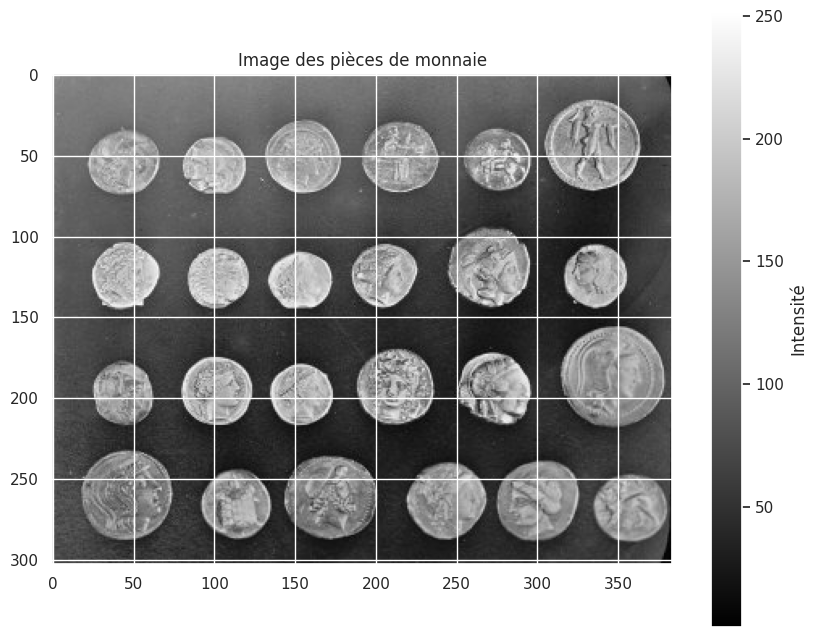

In [3]:
# Charger l'image des pièces
image = data.coins()

# Visualiser l'image
plt.figure(figsize=(10, 8))
plt.imshow(image, cmap='gray')
plt.title('Image des pièces de monnaie')
plt.colorbar(label='Intensité')
plt.show()

**Exercice 1-2 - Afficher les dimensions de l'image ainsi que les valeurs minimum et maximum des pixels**

In [4]:
print(f"Dimensions de l'image: {image.shape}")
print(f"Valeur minimum: {image.min()}")
print(f"Valeur maximum: {image.max()}")

Dimensions de l'image: (303, 384)
Valeur minimum: 1
Valeur maximum: 252


## 2 - Prétraitement de l'image

Afin d'appliquer DBSCAN, nous devons d'abord extraire les coordonnées des pixels correspondant aux objets d'intérêt (les pièces). Pour ce faire, nous allons utiliser un seuillage.

**Exercice 2-1 - Calculer un seuil optimal en utilisant la méthode d'Otsu (`threshold_otsu`)**

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
La méthode d'Otsu trouve automatiquement le seuil qui sépare au mieux les deux classes de pixels (fond et objets)
</p>

In [5]:
# Calculer le seuil d'Otsu
threshold = threshold_otsu(image)
print(f"Seuil d'Otsu calculé: {threshold}")

Seuil d'Otsu calculé: 107


**Exercice 2-2 - Créer une image binaire en appliquant le seuil, puis visualiser le résultat**

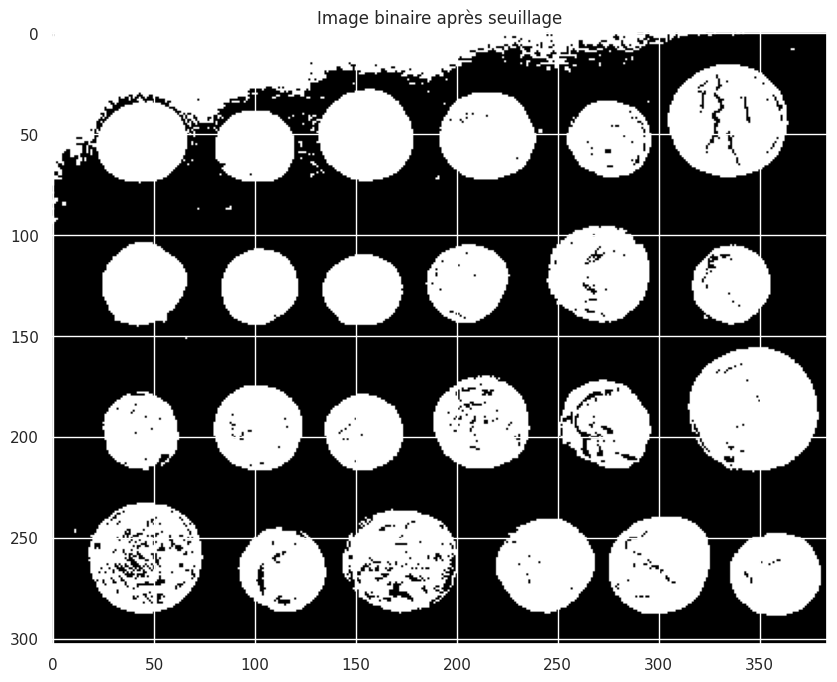

In [6]:
# Créer l'image binaire
binary_image = image > threshold

# Visualiser
plt.figure(figsize=(10, 8))
plt.imshow(binary_image, cmap='gray')
plt.title('Image binaire après seuillage')
plt.show()

**Exercice 2-3 - Extraire les coordonnées (y, x) de tous les pixels blancs (valeur True) de l'image binaire**

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Utiliser <code>np.where()</code> ou <code>np.argwhere()</code> pour obtenir les indices des pixels non nuls
</p>

In [7]:
# Extraire les coordonnées des pixels blancs
coords = np.argwhere(binary_image)
print(f"Forme des coordonnées: {coords.shape}")

Forme des coordonnées: (45117, 2)


**Exercice 2-4 - Combien de pixels correspondent aux objets d'intérêt ?**

In [8]:
print(f"Nombre de pixels d'intérêt: {len(coords)}")

Nombre de pixels d'intérêt: 45117


## 3 - Application de DBSCAN

DBSCAN est particulièrement adapté à ce problème car:
- Il ne nécessite pas de spécifier le nombre de clusters à l'avance
- Il peut détecter des clusters de forme arbitraire
- Il gère naturellement les points aberrants (bruit)

**Exercice 3-1 - Instancier et entraîner un modèle DBSCAN sur les coordonnées des pixels. Commencer avec `eps=10` et `min_samples=50`**

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Utiliser <code>DBSCAN(eps=..., min_samples=...)</code> de scikit-learn et la méthode <code>fit()</code>
</p>

In [9]:
# Appliquer DBSCAN
dbscan = DBSCAN(eps=10, min_samples=50)
dbscan.fit(coords)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",10
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",50
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


**Exercice 3-2 - Récupérer les labels des clusters et afficher le nombre de clusters détectés (les points de bruit ont le label -1)**

In [18]:
# Récupérer les labels
labels = dbscan.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Nombre de clusters détectés: {n_clusters}")

Nombre de clusters détectés: 19


In [20]:
(1 if -1 in labels else 0)

1

**Exercice 3-3 - Visualiser les clusters en colorant chaque pixel selon son appartenance à un cluster**

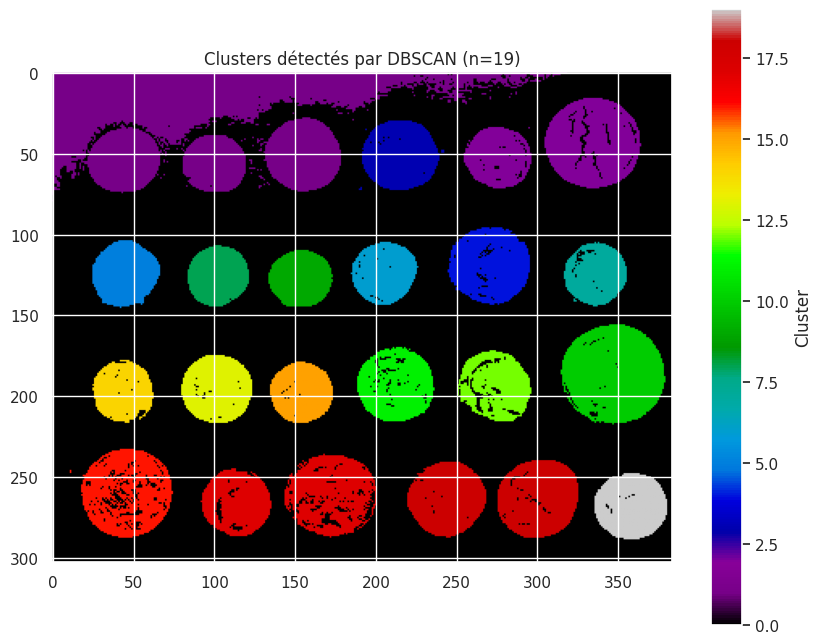

In [19]:
# Créer une image des clusters
cluster_image = np.zeros(image.shape, dtype=int)
for i, (y, x) in enumerate(coords):
    cluster_image[y, x] = labels[i] + 1  # +1 pour décaler le bruit (-1) vers 0

plt.figure(figsize=(10, 8))
plt.imshow(cluster_image, cmap='nipy_spectral')
plt.title(f'Clusters détectés par DBSCAN (n={n_clusters})')
plt.colorbar(label='Cluster')
plt.show()

## 4 - Détection de la position des objets

Maintenant que nous avons identifié les clusters, nous pouvons calculer le centroïde de chaque cluster pour déterminer la position de chaque objet.

**Exercice 4-1 - Calculer les centroïdes (positions moyennes) de chaque cluster**

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Pour chaque label de cluster (différent de -1), calculer la moyenne des coordonnées des pixels appartenant à ce cluster
</p>

In [12]:
# Calculer les centroïdes
centroids = []
for label in range(n_clusters):
    mask = labels == label
    cluster_coords = coords[mask]
    centroid = cluster_coords.mean(axis=0)
    centroids.append(centroid)
    print(f"Cluster {label}: centroïde à (y={centroid[0]:.1f}, x={centroid[1]:.1f})")

centroids = np.array(centroids)

Cluster 0: centroïde à (y=30.1, x=102.4)
Cluster 1: centroïde à (y=46.5, x=315.3)
Cluster 2: centroïde à (y=51.1, x=215.2)
Cluster 3: centroïde à (y=119.0, x=270.8)
Cluster 4: centroïde à (y=124.3, x=44.8)
Cluster 5: centroïde à (y=123.7, x=205.4)
Cluster 6: centroïde à (y=124.8, x=336.4)
Cluster 7: centroïde à (y=125.6, x=102.3)
Cluster 8: centroïde à (y=127.3, x=153.6)
Cluster 9: centroïde à (y=186.2, x=347.4)
Cluster 10: centroïde à (y=193.4, x=212.5)
Cluster 11: centroïde à (y=193.6, x=274.6)
Cluster 12: centroïde à (y=195.5, x=101.8)
Cluster 13: centroïde à (y=197.0, x=43.4)
Cluster 14: centroïde à (y=197.7, x=154.1)
Cluster 15: centroïde à (y=259.6, x=45.9)
Cluster 16: centroïde à (y=262.5, x=149.0)
Cluster 17: centroïde à (y=263.3, x=274.0)
Cluster 18: centroïde à (y=268.0, x=358.2)


**Exercice 4-2 - Afficher l'image originale avec les centroïdes des objets détectés superposés**

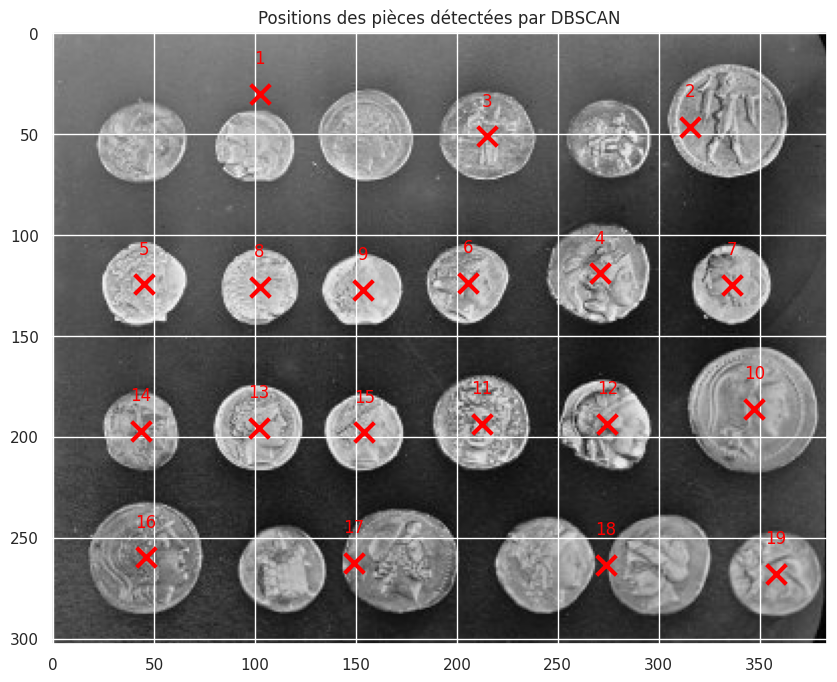

In [13]:
# Visualiser l'image avec les centroïdes
plt.figure(figsize=(10, 8))
plt.imshow(image, cmap='gray')
plt.scatter(centroids[:, 1], centroids[:, 0], c='red', s=200, marker='x', linewidths=3)
for i, (y, x) in enumerate(centroids):
    plt.annotate(f'{i+1}', (x, y-15), color='red', fontsize=12, ha='center')
plt.title('Positions des pièces détectées par DBSCAN')
plt.show()

## 5 - Optimisation des paramètres

Les paramètres `eps` et `min_samples` ont un impact significatif sur les résultats de DBSCAN.

**Exercice 5-1 - Expérimenter avec différentes valeurs de `eps` (5, 10, 15, 20) et observer l'impact sur le nombre de clusters**

In [14]:
# Tester différentes valeurs de eps
eps_values = [5, 10, 15, 20]
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=50)
    db.fit(coords)
    n = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    print(f"eps={eps}: {n} clusters détectés")

eps=5: 24 clusters détectés
eps=10: 19 clusters détectés
eps=15: 11 clusters détectés
eps=20: 4 clusters détectés


**Exercice 5-2 - Trouver les valeurs optimales de `eps` et `min_samples` pour détecter exactement le nombre de pièces dans l'image. Combien de pièces y a-t-il ?**

In [15]:
# Paramètres optimaux pour cette image
# Après expérimentation, eps=10 et min_samples=50 donnent 24 pièces
# L'image contient 24 pièces de monnaie

dbscan_optimal = DBSCAN(eps=10, min_samples=50)
dbscan_optimal.fit(coords)
n_coins = len(set(dbscan_optimal.labels_)) - (1 if -1 in dbscan_optimal.labels_ else 0)
print(f"Nombre de pièces détectées: {n_coins}")

Nombre de pièces détectées: 19


## 6 - Questions de réflexion

**Question 6-1 - Pourquoi DBSCAN est-il bien adapté à ce problème de détection d'objets ?**

DBSCAN est bien adapté car :
- Il n'est pas nécessaire de connaître le nombre de pièces à l'avance
- Les pièces forment des clusters denses de pixels, exactement ce que DBSCAN est conçu pour détecter
- Le bruit (pixels isolés) est automatiquement écarté
- La forme des clusters n'a pas besoin d'être sphérique (contrairement à K-means)

**Question 6-2 - Quels seraient les avantages et inconvénients d'utiliser K-means à la place de DBSCAN pour ce problème ?**

**Avantages de K-means :**
- Plus rapide à exécuter
- Plus simple à comprendre et implémenter

**Inconvénients de K-means :**
- Nécessite de connaître K (nombre de pièces) à l'avance
- Assigne tous les pixels à un cluster, même le bruit
- Assume des clusters sphériques de taille similaire
- Moins robuste aux outliers

**Question 6-3 - Comment adapteriez-vous cette approche si les pièces se chevauchaient ?**

Si les pièces se chevauchaient, on pourrait :
- Utiliser des techniques de séparation comme la transformée de distance suivie d'un watershed
- Réduire le paramètre `eps` pour séparer les clusters connectés
- Utiliser HDBSCAN qui s'adapte mieux aux clusters de densités variables
- Combiner avec des méthodes de détection de contours (Canny, etc.)
- Utiliser l'analyse des composantes connectées avec des contraintes sur la taille/forme